# Model training and comparison

GuidaPlate trains **two complementary models**:

- **Model 1 (Tabular / real data)**: Logistic Regression + Random Forest + (optional) XGBoost on NHANES `ckd_patients_clean.csv`.
- **Model 2 (Sequential / synthetic data)**: LSTM on synthetic `(30 days × 5 features)` sequences.

This notebook also computes a **rule-based baseline** from `config.DIETARY_RISK_THRESHOLDS` and saves test splits for evaluation.


## Section 1 — Setup and imports


In [1]:
import sys
from pathlib import Path


def project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "config.py").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Run from the GUIDAPLATE repo (config.py not found).")


ROOT = project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "app") not in sys.path:
    sys.path.insert(0, str(ROOT / "app"))

import importlib

import config
importlib.reload(config)
import utils

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Optional: XGBoost (may require OpenMP runtime on macOS)
XGB_AVAILABLE = False
try:
    import xgboost as xgb  # type: ignore

    XGB_AVAILABLE = True
except Exception as e:
    xgb = None  # type: ignore
    print("[warn] xgboost unavailable; will use fallback gradient booster.")
    print("       ", repr(e))

# Load both datasets (shapes only here; full pipelines run below)
real_df = utils.load_csv(config.CKD_PATIENTS_CLEAN_CSV, low_memory=False)
seq = np.load(config.SYNTHETIC_SEQUENCES_NPY)
lab = pd.read_csv(config.SYNTHETIC_LABELS_CSV)

print("Real NHANES df:", real_df.shape)
print("Synthetic sequences:", seq.shape)
print("Synthetic labels:", lab.shape)
print("tensorflow:", tf.__version__)
print("XGBoost available:", XGB_AVAILABLE)


/Users/jade/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Real NHANES df: (1769, 17)
Synthetic sequences: (1000, 30, 5)
Synthetic labels: (1000, 5)
tensorflow: 2.20.0
XGBoost available: True


## Section 2 — Random Forest Pipeline (NHANES tabular)

Train **Logistic Regression**, **Random Forest**, and **XGBoost** (or fallback booster) on real NHANES features.


## Section 3 — LSTM Pipeline (synthetic sequences)

Train an LSTM on `synthetic_sequences.npy` with class weighting and early stopping.


## Section 4 — Baseline Rule Based Model

Pure threshold logic from `config.DIETARY_RISK_THRESHOLDS` using the **composite rule** (≥2 nutrients over threshold OR any nutrient >150% of threshold).


## Section 5 — Full Model Comparison

Compare **Rule Based | LR | RF | XGBoost | LSTM** on accuracy, precision, recall, F1, AUC-ROC, sensitivity, specificity.


## Section 6 — Save Test Split

Save RF/LR/XGB test split and LSTM test split for the evaluation notebook.


_Sections 2–6 run in the next code cell so variables remain in scope._


Real tabular X: (1769, 11) y: (1769,)
Real label distribution: {0: 793, 1: 976}
Real nutrient violations (mean > threshold):
K      333
P      936
Pr     581
Na    1262

Tabular model metrics (real test set)
LogReg {'accuracy': 0.9463276836158192, 'precision': 0.9631578947368421, 'recall': 0.9384615384615385, 'f1': 0.9506493506493506, 'auc_roc': 0.9901628769553298, 'sensitivity': 0.9384615384615385, 'specificity': 0.9559748427672956}
RandomForest {'accuracy': 0.9548022598870056, 'precision': 0.9685863874345549, 'recall': 0.9487179487179487, 'f1': 0.9585492227979274, 'auc_roc': 0.9904370262860829, 'sensitivity': 0.9487179487179487, 'specificity': 0.9622641509433962}
XGBoost {'accuracy': 0.9548022598870056, 'precision': 0.958974358974359, 'recall': 0.958974358974359, 'f1': 0.958974358974359, 'auc_roc': 0.993742944686341, 'sensitivity': 0.958974358974359, 'specificity': 0.949685534591195}


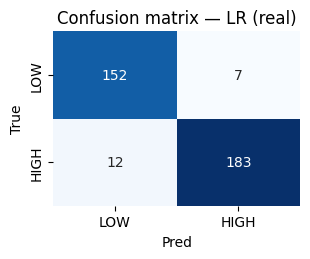

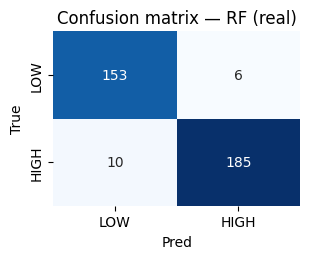

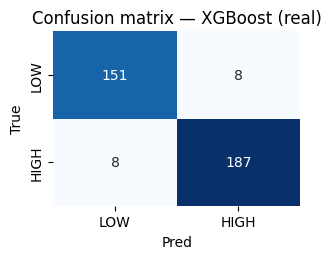

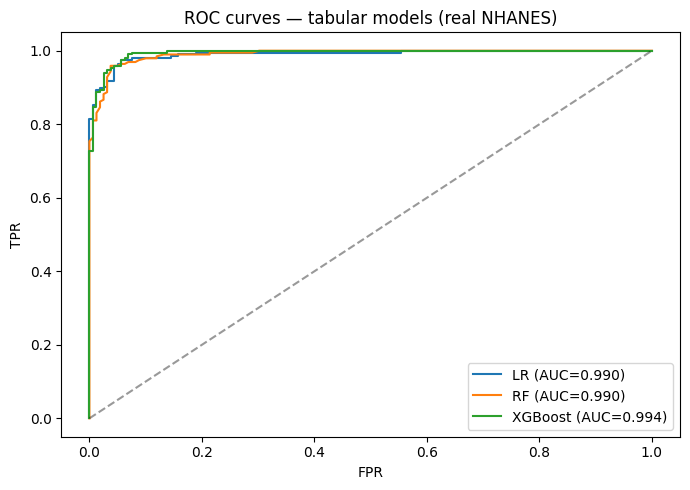


Tabular comparison table (real):
         accuracy  precision    recall        f1   auc_roc  sensitivity  \
model                                                                     
LR       0.946328   0.963158  0.938462  0.950649  0.990163     0.938462   
RF       0.954802   0.968586  0.948718  0.958549  0.990437     0.948718   
XGBoost  0.954802   0.958974  0.958974  0.958974  0.993743     0.958974   

         specificity  
model                 
LR          0.955975  
RF          0.962264  
XGBoost     0.949686  

Best tabular model: XGBoost

Synthetic sequences: (1000, 30, 5) Synthetic y: (1000,)
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5764 - loss: 0.6671 - val_accuracy: 0.8000 - val_loss: 0.5066
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8653 - loss: 0.4464 - val_accuracy: 1.0000 - val_loss: 0.1666
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.1419 - val_accuracy: 1.0000 - val_loss: 0.0309
Epoch 4/50

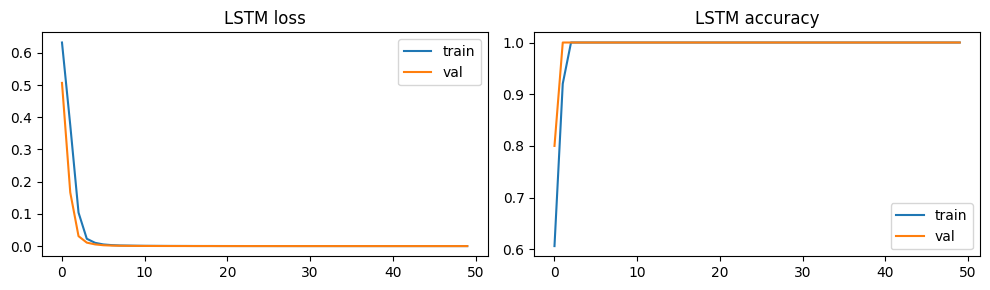


LSTM metrics (synthetic test set):
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'auc_roc': 1.0, 'sensitivity': 1.0, 'specificity': 1.0}


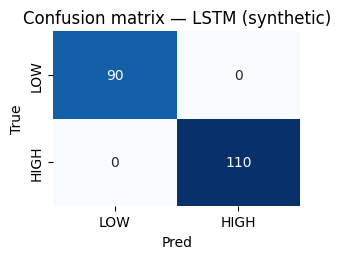


Rule-based baseline metrics (real test set):
{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'auc_roc': 1.0, 'sensitivity': 1.0, 'specificity': 1.0}


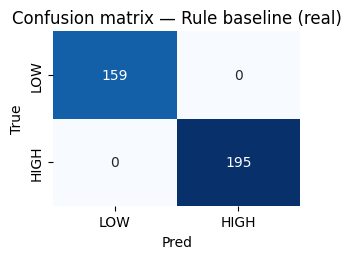


Full comparison table:
            accuracy  precision    recall        f1   auc_roc  sensitivity  \
model                                                                        
Rule Based  1.000000   1.000000  1.000000  1.000000  1.000000     1.000000   
LR          0.946328   0.963158  0.938462  0.950649  0.990163     0.938462   
RF          0.954802   0.968586  0.948718  0.958549  0.990437     0.948718   
XGBoost     0.954802   0.958974  0.958974  0.958974  0.993743     0.958974   
LSTM        1.000000   1.000000  1.000000  1.000000  1.000000     1.000000   

            specificity  
model                    
Rule Based     1.000000  
LR             0.955975  
RF             0.962264  
XGBoost        0.949686  
LSTM           1.000000  


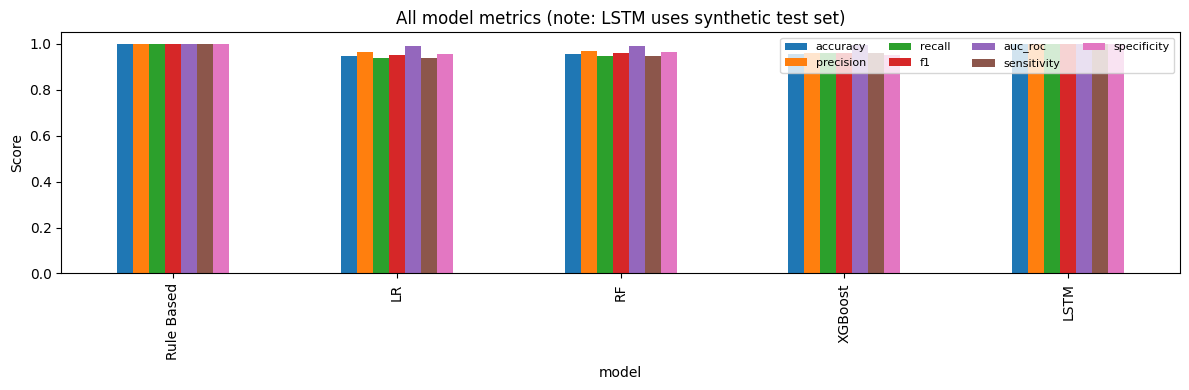

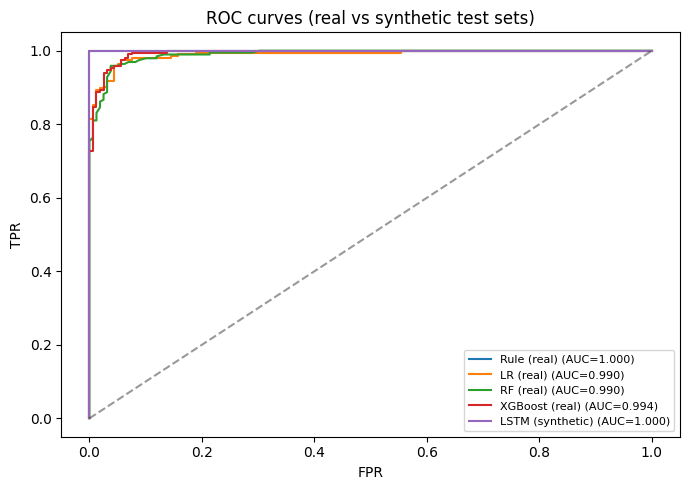


Saved artifacts:
  Tabular best model: /Users/jade/GUIDAPLATE/models/xgboost.pkl
  RF/LR/XGB scaler: /Users/jade/GUIDAPLATE/models/rf_scaler.pkl
  LSTM model: /Users/jade/GUIDAPLATE/models/lstm_model.h5
  LSTM scaler: /Users/jade/GUIDAPLATE/models/lstm_scaler.pkl
  RF test split: /Users/jade/GUIDAPLATE/models/rf_test_split.npz
  LSTM test split: /Users/jade/GUIDAPLATE/models/lstm_test_split.npz

Done.


In [4]:
# ============================================================
# Section 2 — Random Forest Pipeline (NHANES tabular)
# ============================================================

RANDOM_SEED = int(getattr(config, "RANDOM_SEED", 42))

REAL_FEATURES = [
    "ckd_stage_encoded",
    "RIDAGEYR",
    "RIAGENDR",
    "DR1TPOTA",
    "DR1TPHOS",
    "DR1TPROT",
    "DR1TSODI",
    "DR2TPOTA",
    "DR2TPHOS",
    "DR2TPROT",
    "DR2TSODI",
]


def combine_day12(frame: pd.DataFrame, c1: str, c2: str) -> pd.Series:
    a = pd.to_numeric(frame[c1], errors="coerce")
    b = pd.to_numeric(frame[c2], errors="coerce")
    return pd.concat([a, b], axis=1).mean(axis=1, skipna=True)


def thr_series(stage_series: pd.Series, key: str) -> pd.Series:
    return stage_series.map(
        lambda s: float(config.DIETARY_RISK_THRESHOLDS.get(str(s), {}).get(key, float("nan")))
    )


def make_composite_labels_real(df_in: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    """Composite rule labels on Day1/2 combined means.

    HIGH if:
      - 2+ nutrients exceed their stage threshold (mean across Day1/Day2), OR
      - any single nutrient exceeds 150% of its stage threshold.

    Returns:
      - y (0/1)
      - violations_df with columns K,P,Pr,Na (mean > threshold)
    """
    x = df_in.copy()
    x["K_mean"] = combine_day12(x, "DR1TPOTA", "DR2TPOTA")
    x["P_mean"] = combine_day12(x, "DR1TPHOS", "DR2TPHOS")
    x["Pr_mean"] = combine_day12(x, "DR1TPROT", "DR2TPROT")
    x["Na_mean"] = combine_day12(x, "DR1TSODI", "DR2TSODI")

    thr_k = thr_series(x["CKD_stage"], "potassium")
    thr_p = thr_series(x["CKD_stage"], "phosphorus")
    thr_pr = thr_series(x["CKD_stage"], "protein")
    thr_na = thr_series(x["CKD_stage"], "sodium")

    vk = x["K_mean"].notna() & thr_k.notna()
    vp = x["P_mean"].notna() & thr_p.notna()
    vpr = x["Pr_mean"].notna() & thr_pr.notna()
    vna = x["Na_mean"].notna() & thr_na.notna()

    viol_k = vk & (x["K_mean"] > thr_k)
    viol_p = vp & (x["P_mean"] > thr_p)
    viol_pr = vpr & (x["Pr_mean"] > thr_pr)
    viol_na = vna & (x["Na_mean"] > thr_na)

    n_over = viol_k.astype(int) + viol_p.astype(int) + viol_pr.astype(int) + viol_na.astype(int)
    multi_high = n_over >= 2
    severe = (
        (vk & (x["K_mean"] > thr_k * 1.5))
        | (vp & (x["P_mean"] > thr_p * 1.5))
        | (vpr & (x["Pr_mean"] > thr_pr * 1.5))
        | (vna & (x["Na_mean"] > thr_na * 1.5))
    )

    y = (multi_high | severe).astype(int)
    vdf = pd.DataFrame({"K": viol_k, "P": viol_p, "Pr": viol_pr, "Na": viol_na})
    return y, vdf


from typing import Optional


def bin_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: Optional[np.ndarray] = None,
) -> dict:
    acc = float(accuracy_score(y_true, y_pred))
    prec = float(precision_score(y_true, y_pred, zero_division=0))
    rec = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = float(tp / (tp + fn)) if (tp + fn) else float("nan")
    spec = float(tn / (tn + fp)) if (tn + fp) else float("nan")
    aucv = float(roc_auc_score(y_true, y_score)) if y_score is not None else float("nan")
    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc_roc": aucv,
        "sensitivity": sens,
        "specificity": spec,
        "cm": cm,
    }


def plot_cm(cm: np.ndarray, title: str) -> None:
    plt.figure(figsize=(3.2, 2.7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["LOW", "HIGH"],
        yticklabels=["LOW", "HIGH"],
    )
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()


def safe_proba(model, X: np.ndarray) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s = (s - s.min()) / (s.max() - s.min() + 1e-12)
        return s
    p = model.predict(X)
    return np.asarray(p, dtype=float)


# Load + label real dataset
real_df = utils.load_csv(config.CKD_PATIENTS_CLEAN_CSV, low_memory=False)
y_real, viol_real = make_composite_labels_real(real_df)

# Build feature matrix (drop rows with missing feature values)
X_real_df = real_df.copy()
for c in REAL_FEATURES:
    X_real_df[c] = pd.to_numeric(X_real_df[c], errors="coerce")

mask = X_real_df[REAL_FEATURES].notna().all(axis=1) & y_real.notna() & real_df["CKD_stage"].notna()
X_real = X_real_df.loc[mask, REAL_FEATURES].to_numpy(dtype=float)
y_real_np = y_real.loc[mask].to_numpy(dtype=int)
idx_real = X_real_df.index[mask].to_numpy()

print("Real tabular X:", X_real.shape, "y:", y_real_np.shape)
print("Real label distribution:", dict(pd.Series(y_real_np).value_counts().sort_index()))
print("Real nutrient violations (mean > threshold):")
print(viol_real.loc[mask].sum().to_string())

# Split (keep row indices for baseline + eval notebooks)
Xr_train, Xr_test, yr_train, yr_test, idx_real_train, idx_real_test = train_test_split(
    X_real,
    y_real_np,
    idx_real,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_real_np,
)

rf_scaler = MinMaxScaler()
Xr_train_s = rf_scaler.fit_transform(Xr_train)
Xr_test_s = rf_scaler.transform(Xr_test)

# Class weights (for LR/RF and for sample_weight on boosters)
classes = np.unique(yr_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=yr_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
sample_weight = np.vectorize(class_weight.get)(yr_train)

# Models
lr = LogisticRegression(max_iter=5000, class_weight="balanced")
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    class_weight="balanced",
    n_jobs=-1,
)

if XGB_AVAILABLE and xgb is not None:
    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        eval_metric="logloss",
    )
    xgb_name = "XGBoost"
else:
    # Fallback if XGBoost can't load (e.g. missing libomp on macOS)
    xgb_model = HistGradientBoostingClassifier(
        max_depth=4,
        learning_rate=0.05,
        max_iter=400,
        random_state=RANDOM_SEED,
    )
    xgb_name = "Booster (fallback)"

# Fit
lr.fit(Xr_train_s, yr_train)
rf.fit(Xr_train_s, yr_train)
if xgb_name == "XGBoost":
    xgb_model.fit(Xr_train_s, yr_train, sample_weight=sample_weight)
else:
    xgb_model.fit(Xr_train_s, yr_train)

# Predict + evaluate
pred_lr = lr.predict(Xr_test_s)
score_lr = safe_proba(lr, Xr_test_s)
met_lr = bin_metrics(yr_test, pred_lr, score_lr)

pred_rf = rf.predict(Xr_test_s)
score_rf = safe_proba(rf, Xr_test_s)
met_rf = bin_metrics(yr_test, pred_rf, score_rf)

pred_xgb = xgb_model.predict(Xr_test_s)
score_xgb = safe_proba(xgb_model, Xr_test_s)
met_xgb = bin_metrics(yr_test, pred_xgb, score_xgb)

print("\nTabular model metrics (real test set)")
for name, met in [("RuleBased", None), ("LogReg", met_lr), ("RandomForest", met_rf), (xgb_name, met_xgb)]:
    if met is None:
        continue
    print(name, {k: met[k] for k in ["accuracy", "precision", "recall", "f1", "auc_roc", "sensitivity", "specificity"]})

plot_cm(met_lr["cm"], "Confusion matrix — LR (real)")
plot_cm(met_rf["cm"], "Confusion matrix — RF (real)")
plot_cm(met_xgb["cm"], f"Confusion matrix — {xgb_name} (real)")

# ROC curves (real)
plt.figure(figsize=(7, 5))
for name, score, met in [("LR", score_lr, met_lr), ("RF", score_rf, met_rf), (xgb_name, score_xgb, met_xgb)]:
    fpr, tpr, _ = roc_curve(yr_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={met['auc_roc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curves — tabular models (real NHANES)")
plt.legend()
plt.tight_layout()
plt.show()

cmp_tab = pd.DataFrame(
    [
        {"model": "LR", **{k: met_lr[k] for k in met_lr if k != "cm"}},
        {"model": "RF", **{k: met_rf[k] for k in met_rf if k != "cm"}},
        {"model": xgb_name, **{k: met_xgb[k] for k in met_xgb if k != "cm"}},
    ]
).set_index("model")
print("\nTabular comparison table (real):")
print(cmp_tab)

# Pick best tabular model (AUC then F1)
def _rank_key(m: dict) -> tuple[float, float]:
    return (float(m.get("auc_roc", float("nan"))), float(m.get("f1", float("nan"))))

best_name, best_model, best_metrics, best_score = max(
    [
        ("LR", lr, met_lr, score_lr),
        ("RF", rf, met_rf, score_rf),
        (xgb_name, xgb_model, met_xgb, score_xgb),
    ],
    key=lambda t: _rank_key(t[2]),
)
print("\nBest tabular model:", best_name)

# Save tabular artifacts
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
rf_scaler_path = config.MODELS_DIR / "rf_scaler.pkl"
joblib.dump(rf_scaler, rf_scaler_path)

saved_tabular_model_path = None
if best_name == "RF":
    saved_tabular_model_path = config.RANDOM_FOREST_PATH
elif best_name == xgb_name:
    saved_tabular_model_path = config.XGBOOST_MODEL_PATH
else:
    saved_tabular_model_path = config.MODELS_DIR / "log_reg.pkl"

joblib.dump(best_model, saved_tabular_model_path)


# ============================================================
# Section 3 — LSTM Pipeline (synthetic sequences)
# ============================================================

seq = np.load(config.SYNTHETIC_SEQUENCES_NPY)
lab = pd.read_csv(config.SYNTHETIC_LABELS_CSV)

y_syn = pd.to_numeric(lab["risk_label"], errors="coerce").astype(int).to_numpy()

print("\nSynthetic sequences:", seq.shape, "Synthetic y:", y_syn.shape)

idx = np.arange(len(y_syn))
idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_syn,
)

X_train_seq = seq[idx_train].astype(np.float32)
X_test_seq = seq[idx_test].astype(np.float32)
y_train_seq = y_syn[idx_train]
y_test_seq = y_syn[idx_test]

# Scale all 5 channels with one MinMaxScaler fit on train only
lstm_scaler = MinMaxScaler()
X_train_2d = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_test_2d = X_test_seq.reshape(-1, X_test_seq.shape[-1])
X_train_2d_s = lstm_scaler.fit_transform(X_train_2d)
X_test_2d_s = lstm_scaler.transform(X_test_2d)
X_train_seq_s = X_train_2d_s.reshape(X_train_seq.shape)
X_test_seq_s = X_test_2d_s.reshape(X_test_seq.shape)

classes = np.unique(y_train_seq)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
class_weight_lstm = {int(c): float(w) for c, w in zip(classes, cw)}

keras.utils.set_random_seed(RANDOM_SEED)

lstm = keras.Sequential(
    [
        layers.Input(shape=(X_train_seq_s.shape[1], X_train_seq_s.shape[2])),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

hist = lstm.fit(
    X_train_seq_s,
    y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    class_weight=class_weight_lstm,
    verbose=1,
)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.title("LSTM loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val")
plt.title("LSTM accuracy")
plt.legend()
plt.tight_layout()
plt.show()

score_lstm = lstm.predict(X_test_seq_s, verbose=0).reshape(-1)
pred_lstm = (score_lstm >= 0.5).astype(int)
met_lstm = bin_metrics(y_test_seq, pred_lstm, score_lstm)

print("\nLSTM metrics (synthetic test set):")
print({k: met_lstm[k] for k in ["accuracy", "precision", "recall", "f1", "auc_roc", "sensitivity", "specificity"]})

plot_cm(met_lstm["cm"], "Confusion matrix — LSTM (synthetic)")

# Save LSTM artifacts
lstm_model_path = config.LSTM_MODEL_PATH
lstm.save(lstm_model_path)

lstm_scaler_path = config.MODELS_DIR / "lstm_scaler.pkl"
joblib.dump(lstm_scaler, lstm_scaler_path)


# ============================================================
# Section 4 — Baseline Rule Based Model (real NHANES)
# ============================================================

# Baseline prediction is the composite rule itself on the held-out real test rows
# (serves as a benchmark for the tabular ML models)

real_test_rows = real_df.loc[idx_real_test]
y_rule_pred, _ = make_composite_labels_real(real_test_rows)

score_rule = y_rule_pred.to_numpy(dtype=float)
met_rule = bin_metrics(yr_test, y_rule_pred.to_numpy(dtype=int), score_rule)

print("\nRule-based baseline metrics (real test set):")
print({k: met_rule[k] for k in ["accuracy", "precision", "recall", "f1", "auc_roc", "sensitivity", "specificity"]})

plot_cm(met_rule["cm"], "Confusion matrix — Rule baseline (real)")


# ============================================================
# Section 5 — Full Model Comparison
# ============================================================

rows = [
    {"model": "Rule Based", **{k: met_rule[k] for k in met_rule if k != "cm"}},
    {"model": "LR", **{k: met_lr[k] for k in met_lr if k != "cm"}},
    {"model": "RF", **{k: met_rf[k] for k in met_rf if k != "cm"}},
    {"model": "XGBoost" if xgb_name == "XGBoost" else xgb_name, **{k: met_xgb[k] for k in met_xgb if k != "cm"}},
    {"model": "LSTM", **{k: met_lstm[k] for k in met_lstm if k != "cm"}},
]

cmp_all = pd.DataFrame(rows).set_index("model")
print("\nFull comparison table:")
print(cmp_all)

# Grouped bar chart (selected metrics)
plot_metrics = ["accuracy", "precision", "recall", "f1", "auc_roc", "sensitivity", "specificity"]
ax = cmp_all[plot_metrics].plot(kind="bar", figsize=(12, 4))
ax.set_title("All model metrics (note: LSTM uses synthetic test set)")
ax.set_ylabel("Score")
ax.legend(loc="upper right", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

# ROC curves on one chart (note: different test sets)
plt.figure(figsize=(7, 5))
for name, y_true, score in [
    ("Rule (real)", yr_test, score_rule),
    ("LR (real)", yr_test, score_lr),
    ("RF (real)", yr_test, score_rf),
    (f"{xgb_name} (real)", yr_test, score_xgb),
    ("LSTM (synthetic)", y_test_seq, score_lstm),
]:
    fpr, tpr, _ = roc_curve(y_true, score)
    aucv = roc_auc_score(y_true, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={aucv:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curves (real vs synthetic test sets)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# Section 6 — Save Test Split
# ============================================================

rf_test_npz = config.MODELS_DIR / "rf_test_split.npz"
lstm_test_npz = config.MODELS_DIR / "lstm_test_split.npz"

np.savez_compressed(
    rf_test_npz,
    X_test_scaled=Xr_test_s,
    y_test=yr_test,
    idx_test=idx_real_test,
    feature_names=np.array(REAL_FEATURES, dtype=object),
)

np.savez_compressed(
    lstm_test_npz,
    X_test_seq=X_test_seq_s,
    y_test=y_test_seq,
    idx_test=idx_test,
)

print("\nSaved artifacts:")
print("  Tabular best model:", saved_tabular_model_path)
print("  RF/LR/XGB scaler:", rf_scaler_path)
print("  LSTM model:", lstm_model_path)
print("  LSTM scaler:", lstm_scaler_path)
print("  RF test split:", rf_test_npz)
print("  LSTM test split:", lstm_test_npz)
print("\nDone.")


### Summary

- **Best model for immediate prediction (tabular NHANES)**: choose the best of **RF / (XGBoost) / LR** by AUC-ROC and F1.
- **Best model for sequential prediction (30-day sequences)**: **LSTM**.
